# Parameter selection example - PICO

Created by ronja.reese@northumbria.ac.uk. Run after deltaT optimisation.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from parameter_selection_toolbox import *

# Settings

In [3]:
# Directories
figure_dir = 'figures'
data_path="/media/NAS2/ISMIP7_public/AIS/parameterisations/ocean"

# Constants
ice_density = 918 # [kg/m3]
reso=8000 # model resolution used for melt parameterisation [m]

In [4]:
# parameterisation ensemble table 
p1_name = 'ocean.pico.overturning_coefficent'
p2_name = 'ocean.pico.heat_exchange_coefficent'

pism_present_day_ensemble = "pism_16_ismip7_picotest_zhou_initmip8km"

pism_mathiot_cold_ensemble = "pism_16_ismip7_picotest_Mathiot_cold_initmip8km"
pism_mathiot_warm_ensemble = "pism_16_ismip7_picotest_Mathiot_warm_initmip8km"

pism_naughten_cold_ensemble = "pism_16_ismip7_picotest_NaughtenFA_cold_initmip8km"
pism_naughten_warm_ensemble = "pism_16_ismip7_picotest_NaughtenFA_warm_initmip8km"

pism_dutrieux_2009_ensemble = "pism_16_ismip7_picotest_Dutrieux_2009_initmip8km"
pism_dutrieux_2012_ensemble = "pism_16_ismip7_picotest_Dutrieux_2012_initmip8km"


# Load data

In [5]:
# Load ensembles

deltaTrange = "pm05" # "pm1"

pd_ensemble = xr.load_dataset('Ensemble_'+pism_present_day_ensemble+'_optimaldeltaT_'+deltaTrange+'.nc', drop_variables=['timestamp'])
mathiot_cold_ensemble = xr.load_dataset('Ensemble_'+pism_mathiot_cold_ensemble+'_optimaldeltaT_'+deltaTrange+'.nc', drop_variables=['timestamp'])
mathiot_warm_ensemble = xr.load_dataset('Ensemble_'+pism_mathiot_warm_ensemble+'_optimaldeltaT_'+deltaTrange+'.nc', drop_variables=['timestamp'])
naughten_cold_ensemble = xr.load_dataset('Ensemble_'+pism_naughten_cold_ensemble+'_optimaldeltaT_'+deltaTrange+'.nc', drop_variables=['timestamp'])
naughten_warm_ensemble = xr.load_dataset('Ensemble_'+pism_naughten_warm_ensemble+'_optimaldeltaT_'+deltaTrange+'.nc', drop_variables=['timestamp'])
dutrieux_2009_ensemble = xr.load_dataset('Ensemble_'+pism_dutrieux_2009_ensemble+'_optimaldeltaT_'+deltaTrange+'.nc', drop_variables=['timestamp'])
dutrieux_2012_ensemble = xr.load_dataset('Ensemble_'+pism_dutrieux_2012_ensemble+'_optimaldeltaT_'+deltaTrange+'.nc', drop_variables=['timestamp'])


In [6]:
# combine 

cold_ensemble  = xr.concat([mathiot_cold_ensemble.expand_dims({"model": np.array([0])}), 
                            naughten_cold_ensemble.expand_dims({"model": np.array([1])})], dim='model')
cold_ensemble = cold_ensemble.assign_coords(model=["mathiot", "naughten_ais_1"])

warm_ensemble  = xr.concat([mathiot_warm_ensemble.expand_dims({"model": np.array([0])}), 
                            naughten_warm_ensemble.expand_dims({"model": np.array([1])})], dim='model')
warm_ensemble = warm_ensemble.assign_coords(model=["mathiot", "naughten_ais_1"])


In [7]:
# Combine
obs_ensemble  = xr.concat([dutrieux_2009_ensemble.expand_dims({"year": np.array([0])}),
                           dutrieux_2012_ensemble.expand_dims({"year": np.array([0])})]
                            , dim='year')
obs_ensemble = obs_ensemble.assign_coords(year=[2009, 2012])


In [8]:
# Note that this is accounted for in term 1 calculation
invalid = np.isnan(pd_ensemble.optimal_deltaT_per_basin.mean('basin', skipna=False))

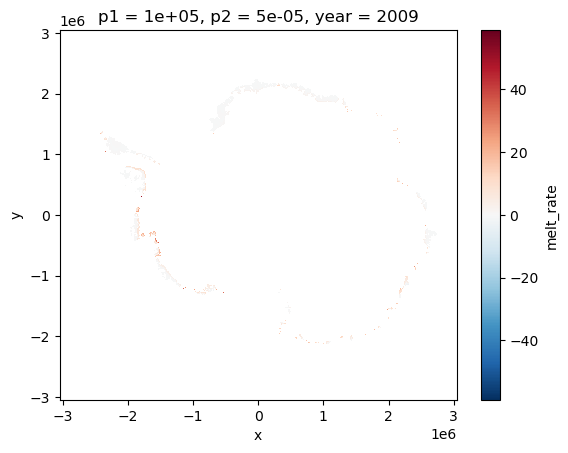

In [9]:
# Plot melt rates, e.g.
obs_ensemble.sel(p1=0.1e6,p2=5e-5,year=2009).melt_rate.plot()

In [10]:
# convert melt rates to kg/m2/a

pd_ensemble['melt_rate'] = pd_ensemble['melt_rate']*ice_density
cold_ensemble['melt_rate'] = cold_ensemble['melt_rate']*ice_density
warm_ensemble['melt_rate'] = warm_ensemble['melt_rate']*ice_density
obs_ensemble['melt_rate'] = obs_ensemble['melt_rate']*ice_density

# Load target data 

In [11]:
MeltDataImbie = pd.read_csv(os.path.join(data_path, 'meltobs','Melt_Paolo_Err_Adusumilli_imbie2_v3.csv'), index_col=0) # Aggregated per imbier basin

buttressing_target = xr.load_dataset(os.path.join(data_path, 'meltobs',"melt_target_term2.nc"))

cold_target = xr.load_dataset(os.path.join(data_path, 'ocean_modelling_data',"melt_cold_target_term3.nc"))
warm_target = xr.load_dataset(os.path.join(data_path, 'ocean_modelling_data',"melt_warm_target_term3.nc"))

t4_obs = xr.load_dataset(os.path.join(data_path, 'ocean_observations_data',"melt_observations_target_term4.nc"))

In [12]:
# Supporting Data

# Load imbie2 basins as used on ISMIP
basins_m = xr.load_dataset(os.path.join(data_path, 'imbie2', "basin_numbers_ismip8km_v2.nc"))
basins_m = basins_m.rename({'basinNumber':'basins'})
nBasins = int(basins_m.basins.max())

# Buttressing Flux Response Numbers, remapped to 8km 
bfrn_m = xr.load_dataset(os.path.join(data_path,'bfrns',"BFRN_ismip8km_v2.nc"))
nBins = 10

In [13]:
mask_m = xr.load_dataset(os.path.join(data_path, 'floatingmasks', 'floatingmask_ismip8km.nc')).mask

In [14]:
# Ice shelf masks for PIG and Dotson for term 4
ds = xr.load_dataset(os.path.join(data_path, "shelfmask", "shelf_mask_ismip8km.nc"))#.isel(time=0)
shelves = ds.shelf_mask.isel(time=0)
pig_id = 110
dis_id = 97
pig = (shelves==pig_id) & (obs_ensemble.x>-1.625e6) # Restrict to main trunk of PIG
dotson = (shelves==dis_id) 
pigdotson_mask = pig.astype(int) + dotson.astype(int) * 2
label_map = {1: "pig", 2: "dotson"}
labels = np.vectorize(label_map.get)(pigdotson_mask.values)
region_label = xr.DataArray(labels, dims=pigdotson_mask.dims, coords=pigdotson_mask.coords)

# Interpolate to model resolution
pigdotson_mask_m = pigdotson_mask.interp(method='nearest')
labels = np.vectorize(label_map.get)(pigdotson_mask_m.values)
region_label_m = xr.DataArray(labels, dims=pigdotson_mask_m.dims, coords=pigdotson_mask_m.coords)

# Optimise

In [15]:
cvt_m = reso**2  / 1e12  # to convert to Gt/a
cvt = 8000**2  / 1e12  # to convert to Gt/a

In [16]:
# Term 1
t1_model, t1_obs_mean, t1_obs_sigma = calculate_term1(
    pd_ensemble,mask_m,basins_m['basins'],nBasins,cvt_m,MeltDataImbie)

In [17]:
# Term 2
t2_model, t2_obs_mean, t2_obs_sigma = calculate_term2(
    pd_ensemble,mask_m,bfrn_m,cvt_m,buttressing_target)

In [18]:
# Term 3
t3_model, t3_obs_mean, t3_obs_sigma = calculate_term3(
    cold_ensemble, warm_ensemble, cold_target, warm_target,
    mask_m,basins_m['basins'])

In [19]:
# Term 4
t4_model, t4_obs_mean, t4_obs_sigma = calculate_term4(obs_ensemble, region_label_m, t4_obs, mask_m, cvt_m)

# Introduce weights

In [20]:
#(basins_m.basins==14).plot()

In [21]:
t1_weights = xr.DataArray(
    t1_obs_mean*0+1,
    dims=["basins"],
    coords={"basins": t1_model.basins.values}
)


In [22]:
# Buttressing Flux Response Numbers, remapped to 8km 
bfrn = xr.load_dataset(os.path.join(data_path, 'bfrns',"BFRN_ismip8km_v2.nc"))

t2_weight = (bfrn['BFRN_medians'] / bfrn['BFRN_median']).values

t2_weights = xr.DataArray(
    t2_weight,
    dims=["BFRN_bins"],
    coords={"BFRN_bins": t2_obs_mean.BFRN_bins.values}
)

In [23]:
weights_data = np.ones(t3_model.isel(p1=0,p2=0).shape) 

t3_weights = xr.DataArray(
    weights_data,
    dims=["model", "basins"],
    coords={"model": t3_model.model.values,
            "basins": t3_model.basins.values}
)


In [24]:
# introduce weights, shape of region, years

weights_data = np.transpose(np.ones(t4_obs.melt_rate.shape))

t4_weights = xr.DataArray(
    weights_data,
    dims=["year", "region"],
    coords={"year": t4_obs.year.values,
            "region": t4_obs.region.values}
)

# Only sample PIG in 2009 and 2012
t4_weights = t4_weights.where(t4_weights.region == "pig", other=0)
t4_weights = t4_weights.where((t4_weights.year ==2009) | (t4_weights.year==2012)  ,other=0)

# Sample

In [25]:
sample_size=10000

min_p1, min_p2 = calculate_objective_function(
    sample_size,
    reso,
    t1_model, t1_obs_mean, t1_obs_sigma,t1_weights,
    t2_model, t2_obs_mean, t2_obs_sigma,t2_weights,
    t3_model, t3_obs_mean, t3_obs_sigma,t3_weights,
    t4_model, t4_obs_mean, t4_obs_sigma,t4_weights)

# Analyse parameter distribution

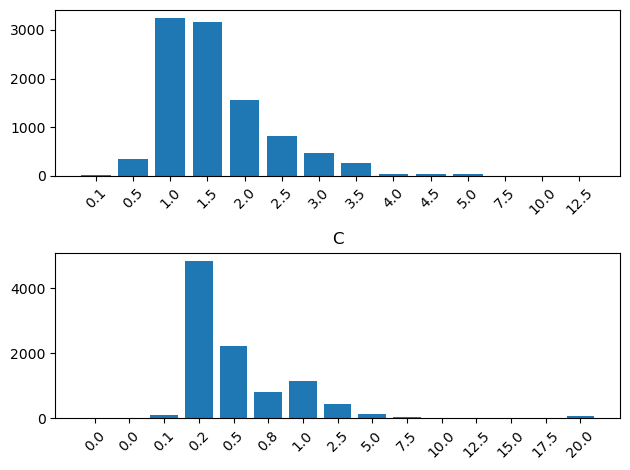

In [26]:
fig,axes = plt.subplots(2,1, sharex=False, sharey=False)
ax = axes.flatten()[0]

bin_edges = np.array( np.append(pd_ensemble.p2.values[0]*0.5, pd_ensemble.p2.values*1.1) )
counts_p1, _ = np.histogram(np.array(min_p2), bins= bin_edges)
positions = np.arange(len(counts_p1))
ax.bar(positions, counts_p1, width=0.8)
labels = np.round(pd_ensemble.p2.values*1e5, 1)
ax.set_xticks(positions, labels, rotation=45)
#ax.set_title('gT')

ax = axes.flatten()[1]
bin_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+0.001e6) )
counts_p2, _ = np.histogram(np.array(min_p1), bins= bin_edges)
positions = np.arange(len(counts_p2))
ax.bar(positions, counts_p2, width=0.8)
labels = np.round(pd_ensemble.p1.values/1e6, 1)
ax.set_xticks(positions, labels, rotation=45)
ax.set_title('C')
plt.tight_layout()

plt.savefig(os.path.join(figure_dir,pism_present_day_ensemble+'_Hists_Sample_'+deltaTrange+'.png'))

<Figure size 640x480 with 0 Axes>

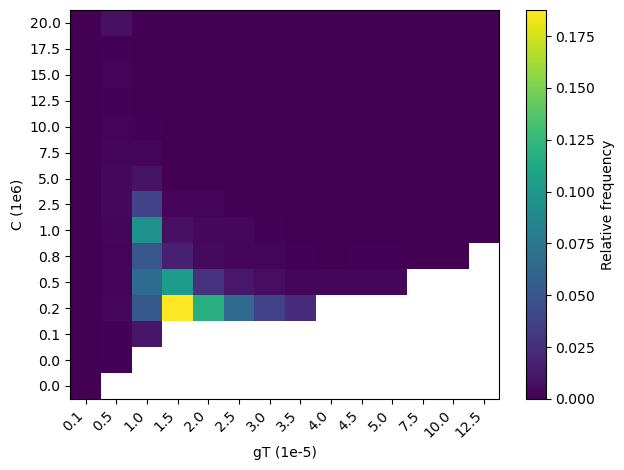

In [27]:
fig,axes = plt.subplots(1,1, sharex=False, sharey=False)
ax = axes

x_edges = np.array( np.append(pd_ensemble.p2.values[0]*0.5, pd_ensemble.p2.values+1e-7) )
y_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+0.001e6) )
counts, _, _ = np.histogram2d(min_p2,np.array(min_p1), bins=[x_edges, y_edges])
plt.clf()

fig, ax = plt.subplots()

counts_masked = np.ma.masked_where(invalid.values==True, counts.T)

im = ax.pcolormesh(np.arange(len(x_edges)), np.arange(len(y_edges)), 
                    #counts.T/sample_size, cmap='viridis', shading='auto', vmin=0 #, vmax=1000
                    counts_masked/sample_size, cmap='viridis', shading='auto', #vmin=0 , vmax=100/sample_size
                  )

y_labels = np.round(pd_ensemble.p1.values/1e6, 1)
x_labels = np.round(pd_ensemble.p2.values*1e5, 1)

# Set tick positions and labels
ax.set_xticks(np.arange(len(x_labels))+0.5)
ax.set_yticks(np.arange(len(y_labels))+0.5)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_yticklabels(y_labels)

ax.set_ylabel("C (1e6)")
ax.set_xlabel("gT (1e-5)")
plt.colorbar(im, label='Relative frequency')
plt.tight_layout()

plt.savefig(os.path.join(figure_dir,pism_present_day_ensemble+'_Hist2D_Sample_'+deltaTrange+'.png'))    

# Select parameters

In [29]:
from scipy.ndimage import gaussian_filter, maximum_filter

smooth = gaussian_filter(counts_masked, sigma=0.005)

#plt.contourf(smooth)

In [30]:
# Find min, max, 5th, 95th, and modes

print('Start exploring global modes:')

local_max = (smooth == maximum_filter(smooth, size=3))
local_max &= smooth > sample_size/100  # optional

mode_indices = np.argwhere(local_max)
modes = np.array([
    [pd_ensemble.p1.values[i], pd_ensemble.p2.values[j]]
    for i,j in mode_indices
])
print(modes)



print('\n\nIndividual stats on C, gT')
print('median: C=', np.median(np.array(min_p1))/1e6, 'x1e6 gT=', np.median(np.array(min_p2)))
print('mode:   C=', pd_ensemble.p1.values[np.argmax(counts_p1) ]/1e6, 'x1e6 gT=', pd_ensemble.p2.values[np.argmax(counts_p2) ])


print('Uncertainty bounds:')
print('5th:    C=', np.percentile(np.array(min_p1), 5)/1e6, 'x1e6 gT=', np.percentile(np.array(min_p2), 5))
print('95th:   C=', np.percentile(np.array(min_p1), 95)/1e6, 'x1e6 gT=', np.percentile(np.array(min_p2), 95))


print('Further options for uncertainty exploration:')
print('min:    C=', np.min(np.array(min_p1))/1e6, 'x1e6 gT=', np.min(np.array(min_p2)))
print('1st:    C=', np.percentile(np.array(min_p1), 1)/1e6, 'x1e6 gT=', np.percentile(np.array(min_p2), 1))
print('99th:   C=', np.percentile(np.array(min_p1), 99)/1e6, 'x1e6 gT=', np.percentile(np.array(min_p2), 99))
print('max:    C=', np.max(np.array(min_p1))/1e6, 'x1e6 gT=', np.max(np.array(min_p2)))

vals = [np.min(np.array(min_p1)), np.percentile(np.array(min_p1), 1), 
        np.percentile(np.array(min_p1), 5), np.median(np.array(min_p1)), 
        np.percentile(np.array(min_p1), 95), np.percentile(np.array(min_p1), 99),
        np.max(np.array(min_p1))
       ]
labs = ['min', '1st', '5th', '50th', '95th', '99th', 'max']


Start exploring global modes:
[[2.5e+05 1.5e-05]
 [2.5e+05 4.5e-05]
 [5.0e+05 2.5e-05]
 [1.0e+06 1.0e-05]
 [2.0e+07 5.0e-06]]


Individual stats on C, gT
median: C= 0.5 x1e6 gT= 1.5e-05
mode:   C= 0.1 x1e6 gT= 2e-05
Uncertainty bounds:
5th:    C= 0.25 x1e6 gT= 1e-05
95th:   C= 5.0 x1e6 gT= 4e-05
Further options for uncertainty exploration:
min:    C= 0.05 x1e6 gT= 1e-06
1st:    C= 0.1 x1e6 gT= 5e-06
99th:   C= 20.0 x1e6 gT= 5e-05
max:    C= 20.0 x1e6 gT= 0.0001


Suggested here: Use the global mode as standard value C=0.5e6, gT=2.5e-5. 

To identify the ranges, it does not make too much sense to use individual 5th and 95th percentiles together, yielding
C=0.25e6,gT=1e-5 and C=5e6, gT=4e-5 as these values are not inside the sampled range, really.

To explore uncertainty, we hence suggest an ad hoc method that samples the corners in all directions, e.g., using the min gT=0.5e-5 with corresponding minimal C=0.1e6; this value corresponds also to the minimal C, then gT selection. For the max, use max gT=5e-5 and corresponding max C=1e6, and max C=20e6 and corresponding gT=0.5e-5.

# Sensitivity of ASE and Filchner Ronne
Trying similar approach as Reese et al., 2023

In [122]:
t1_weights = xr.DataArray(
    t1_obs_mean*0+1,
    dims=["basins"],
    coords={"basins": t1_model.basins.values}
)

t1_weights = t1_weights.where( (t1_weights.basins==9)| (t1_weights.basins==14), other=0)

In [131]:
# Buttressing Flux Response Numbers, remapped to 8km 
bfrn = xr.load_dataset(os.path.join(data_path, 'bfrns',"BFRN_ismip8km_v2.nc"))

t2_weight = (bfrn['BFRN_medians'] / bfrn['BFRN_median']).values

t2_weights = xr.DataArray(
    t2_weight,
    dims=["BFRN_bins"],
    coords={"BFRN_bins": t2_obs_mean.BFRN_bins.values}
)

In [124]:
weights_data = np.ones(t3_model.isel(p1=0,p2=0).shape) 

t3_weights = xr.DataArray(
    weights_data,
    dims=["model", "basins"],
    coords={"model": t3_model.model.values,
            "basins": t3_model.basins.values}
)

t3_weights = t3_weights.where( (t3_weights.basins==9)| (t3_weights.basins==14), other=0)

In [135]:
# introduce weights, shape of region, years

weights_data = np.transpose(np.ones(t4_obs.melt_rate.shape))

t4_weights = xr.DataArray(
    weights_data,
    dims=["year", "region"],
    coords={"year": t4_obs.year.values,
            "region": t4_obs.region.values}
)

# Only sample PIG in 2009 and 2012
t4_weights = t4_weights.where(t4_weights.region == "pig", other=0)
t4_weights = t4_weights.where((t4_weights.year ==2009) | (t4_weights.year==2012)  ,other=0)

In [136]:
sample_size=10000

min_p1, min_p2 = calculate_objective_function(
    sample_size,
    reso,
    t1_model, t1_obs_mean, t1_obs_sigma,t1_weights,
    t2_model, t2_obs_mean, t2_obs_sigma,t2_weights,
    t3_model, t3_obs_mean, t3_obs_sigma,t3_weights,
    t4_model, t4_obs_mean, t4_obs_sigma,t4_weights)

<Figure size 640x480 with 0 Axes>

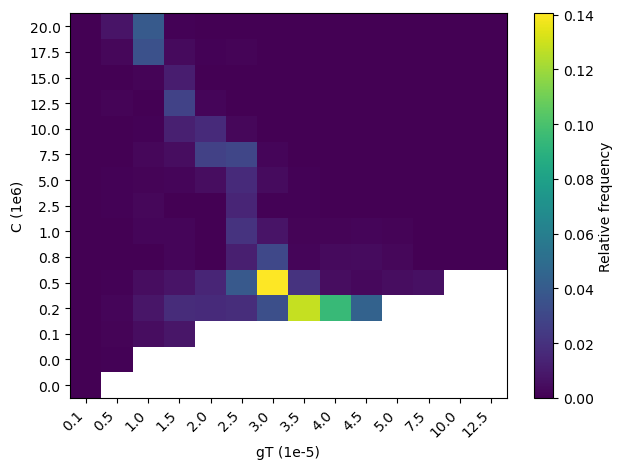

In [137]:
fig,axes = plt.subplots(1,1, sharex=False, sharey=False)
ax = axes

x_edges = np.array( np.append(pd_ensemble.p2.values[0]*0.5, pd_ensemble.p2.values+1e-7) )
y_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+0.001e6) )
counts, _, _ = np.histogram2d(min_p2,np.array(min_p1), bins=[x_edges, y_edges])
plt.clf()

fig, ax = plt.subplots()

counts_masked = np.ma.masked_where(invalid.values==True, counts.T)

im = ax.pcolormesh(np.arange(len(x_edges)), np.arange(len(y_edges)), 
                    #counts.T/sample_size, cmap='viridis', shading='auto', vmin=0 #, vmax=1000
                    counts_masked/sample_size, cmap='viridis', shading='auto', #vmin=0 , vmax=100/sample_size
                  )

y_labels = np.round(pd_ensemble.p1.values/1e6, 1)
x_labels = np.round(pd_ensemble.p2.values*1e5, 1)

# Set tick positions and labels
ax.set_xticks(np.arange(len(x_labels))+0.5)
ax.set_yticks(np.arange(len(y_labels))+0.5)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_yticklabels(y_labels)

ax.set_ylabel("C (1e6)")
ax.set_xlabel("gT (1e-5)")
plt.colorbar(im, label='Relative frequency')
plt.tight_layout()

plt.savefig(os.path.join(figure_dir,pism_present_day_ensemble+'_Hist2D_Sample_Reese23_'+deltaTrange+'.png'))    

# Analyse parameters

In [191]:
C=0.5e6 
gT=2.5e-5

C_05 = 0.1e6
gT_05 =0.5e-5

C_95 = 1e6
gT_95 = 5e-5

In [192]:
result_ds = pd_ensemble.sel(p1=C, p2=gT)

Text(0.5, 1.0, 'Present-day melt rates')

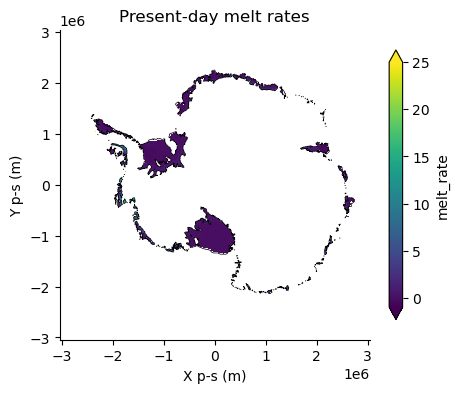

In [193]:
plt.figure(figsize=(5,5))

(result_ds.melt_rate/ice_density).plot( vmin=-1, vmax=25, cmap='viridis',cbar_kwargs={'shrink': 0.7} )
ax = plt.gca()
ax.set_aspect('equal')
ax.set_xlabel('X p-s (m)')
ax.set_ylabel('Y p-s (m)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.contour(result_ds.x, result_ds.y, mask_m,levels=[0.5], colors=['black'], linewidths=0.5)
#plt.contour(result_ds.x, result_ds.y, ,levels=[0.5], colors=['black'], linewidths=0.5)
plt.title('Present-day melt rates')

#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_K'+str(K)+'_pdmelt.png'))  

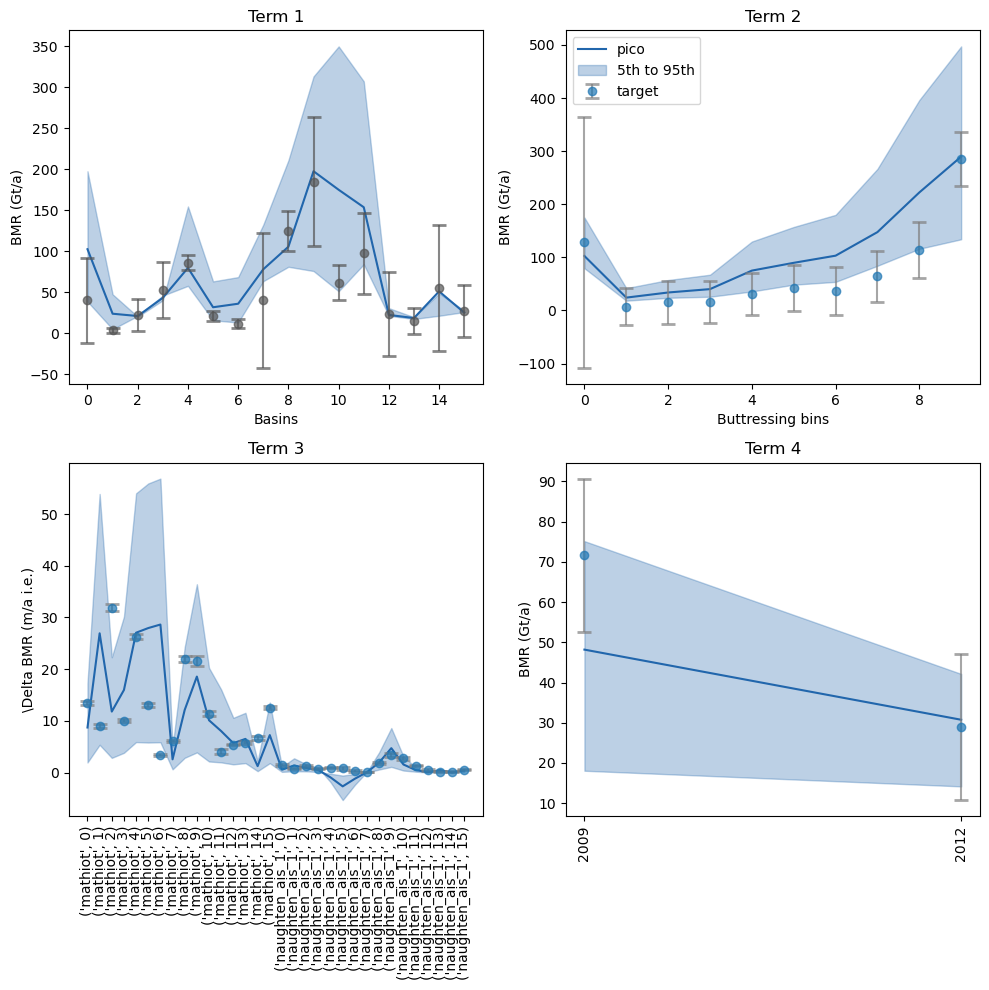

In [197]:
# Basic 2x2 grid

cvt = 8000**2  / 1e12  # to convert to Gt/a
cvt_m = reso**2  / 1e12  # to convert to Gt/a

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

color_wocorrection = "#D6604D"
color_wcorrection = "#2166AC"

# TERM 1
ax = axes.flatten()[0]  

ax.plot(range(nBasins+1),t1_model.sel(p1=C,p2=gT) , label='pico', color=color_wcorrection)
ax.fill_between(range(nBasins+1),t1_model.sel(p1=C_05,p2=gT_05), t1_model.sel(p1=C_95,p2=gT_95),color=color_wcorrection, alpha=0.3, label='5th to 95th')
ax.errorbar(range(nBasins+1), t1_obs_mean, xerr=None, yerr=t1_obs_sigma, 
             fmt='o', capsize=5, capthick=2, color="#555555", 
             ecolor="#555555", alpha=0.7, label='target')
ax.set_ylabel('BMR (Gt/a)')
ax.set_xlabel('Basins')
#plt.text(0,2, 'Modelled average melt = '+str(np.round(np.sum(t2_model).values))+' m/a' )
#plt.text(0,1, 'Observed average melt = '+str(np.round(np.sum(t2_obs_mean).values))+' m/a' )
#ax.legend()
ax.set_title('Term 1')


# TERM 2
ax = axes.flatten()[1]  

ax.plot(range(len(t2_model.BFRN_bins)),t2_model.sel(p1=C,p2=gT) , label='pico', color=color_wcorrection)
ax.fill_between(range(len(t2_model.BFRN_bins)),t2_model.sel(p1=C_05,p2=gT_05), t2_model.sel(p1=C_95,p2=gT_95),color=color_wcorrection, alpha=0.3, label='5th to 95th')

ax.errorbar(range(len(t2_model.BFRN_bins)), t2_obs_mean, xerr=None, yerr=t2_obs_sigma, 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_ylabel('BMR (Gt/a)')
ax.set_xlabel('Buttressing bins')
ax.legend()
ax.set_title('Term 2')


# Term 3
ax = axes.flatten()[2]  

#t3_model_ndT, t3_obs_mean, t3_obs_sigma = calculate_term3(
#    cold_ensemble.sel(p1=C,p2=gT), warm_ensemble.sel(p1=C,p2=gT), cold_target, warm_target, mask_m, basins_m.basins)

t3_stack_ndT = t3_model.sel(p1=C,p2=gT).sel(model=['mathiot', 'naughten_ais_1']).stack(modelbasin=('model','basins')).dropna(dim='modelbasin')

#ax.plot(range(len(t3_stack.modelbasin)),
#        t3_stack/ice_density , label='parameterisation', color=color_wcorrection)
ax.plot(range(len(t3_stack_ndT.modelbasin)),
        t3_stack_ndT/ice_density , label='pico', color=color_wcorrection)
ax.fill_between(range(len(t3_stack_ndT.modelbasin)),
                      t3_model.sel(p1=C_05,p2=gT_05).sel(model=['mathiot', 'naughten_ais_1']).stack(modelbasin=('model','basins')).dropna(dim='modelbasin')/ice_density, 
                      t3_model.sel(p1=C_95,p2=gT_95).sel(model=['mathiot', 'naughten_ais_1']).stack(modelbasin=('model','basins')).dropna(dim='modelbasin')/ice_density,
                color=color_wcorrection, alpha=0.3, label='5th to 95th')

ax.errorbar(range(len(t3_obs_mean.sel(model=['mathiot', 'naughten_ais_1']).stack(modelbasin=('model','basins')).dropna(dim='modelbasin').modelbasin)), 
            t3_obs_mean.sel(model=['mathiot', 'naughten_ais_1']).stack(modelbasin=('model','basins')).dropna(dim='modelbasin')/ice_density, 
            xerr=None, yerr=t3_obs_sigma.sel(model=['mathiot', 'naughten_ais_1']).stack(modelbasin=('model','basins')).dropna(dim='modelbasin')/ice_density, 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_ylabel('\Delta BMR (m/a i.e.)')
ax.set_xticks(range(len(t3_obs_mean.sel(model=['mathiot', 'naughten_ais_1']).stack(modelbasin=('model','basins')).dropna(dim='modelbasin').modelbasin)))
ax.set_xticklabels(t3_obs_mean.sel(model=['mathiot', 'naughten_ais_1']).stack(modelbasin=('model','basins')).dropna(dim='modelbasin').modelbasin.values, rotation=90)
ax.set_title('Term 3')


## Term 4
ax = axes.flatten()[3] 

ds_flat_ndT = t4_model.sel(p1=C,p2=gT).sel(region='pig', year=[2009,2012]) #.stack(region_year=("region", "year")).dropna(dim='region_year') #t4_model.isel(p1=0,p2=0).stack(region_year=("region", "year")).dropna(dim='region_year')


#ax.plot(range(len(ds_flat_ndT.region_year)),ds_flat_ndT.values , label='pico', color=color_wocorrection)
ax.plot(range(len(ds_flat_ndT.year)),ds_flat_ndT.values , label='pico', color=color_wcorrection)
ax.fill_between(range(len(ds_flat_ndT.year)),
                     t4_model.sel(p1=C_05,p2=gT_05).sel(region='pig', year=[2009,2012]) , 
                     t4_model.sel(p1=C_95,p2=gT_95).sel(region='pig', year=[2009,2012]) ,
                color=color_wcorrection, alpha=0.3, label='5th to 95th')


ax.errorbar(range(len(ds_flat_ndT.year)), 
            t4_obs_mean.sel(region='pig', year=[2009,2012]), #.stack(region_year=('region','year')).dropna(dim='region_year'), 
            xerr=None, 
            yerr=t4_obs_sigma.sel(region='pig', year=[2009,2012]), #.stack(region_year=('region','year')).dropna(dim='region_year'),
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_ylabel('BMR (Gt/a)')
ax.set_xticks(range(len(ds_flat_ndT.year)))
ax.set_xticklabels(ds_flat_ndT.year.values, rotation=90)
ax.set_title('Term 4')



plt.tight_layout()

plt.savefig(os.path.join(figure_dir,'Optimise_pico_Terms.png'))  
plt.show()